In [ ]:
from google.colab import files
uploaded=files.upload()

Saving diabetic_data.csv to diabetic_data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)

df["Actual Species"] = y

print("="*60)
print("First Five Rows")
print("="*60)
print(df.head())

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)
print(df.info())

print("\n")

print("="*60)
print("Statistical Summary")
print("="*60)
print(df.describe())



First Five Rows
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Actual Species  
0               0  
1               0  
2               0  
3               0  
4               0  


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)  

In [ ]:

print("\nMissing Values\n")
print(df.isnull().sum())



Missing Values

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Actual Species       0
dtype: int64


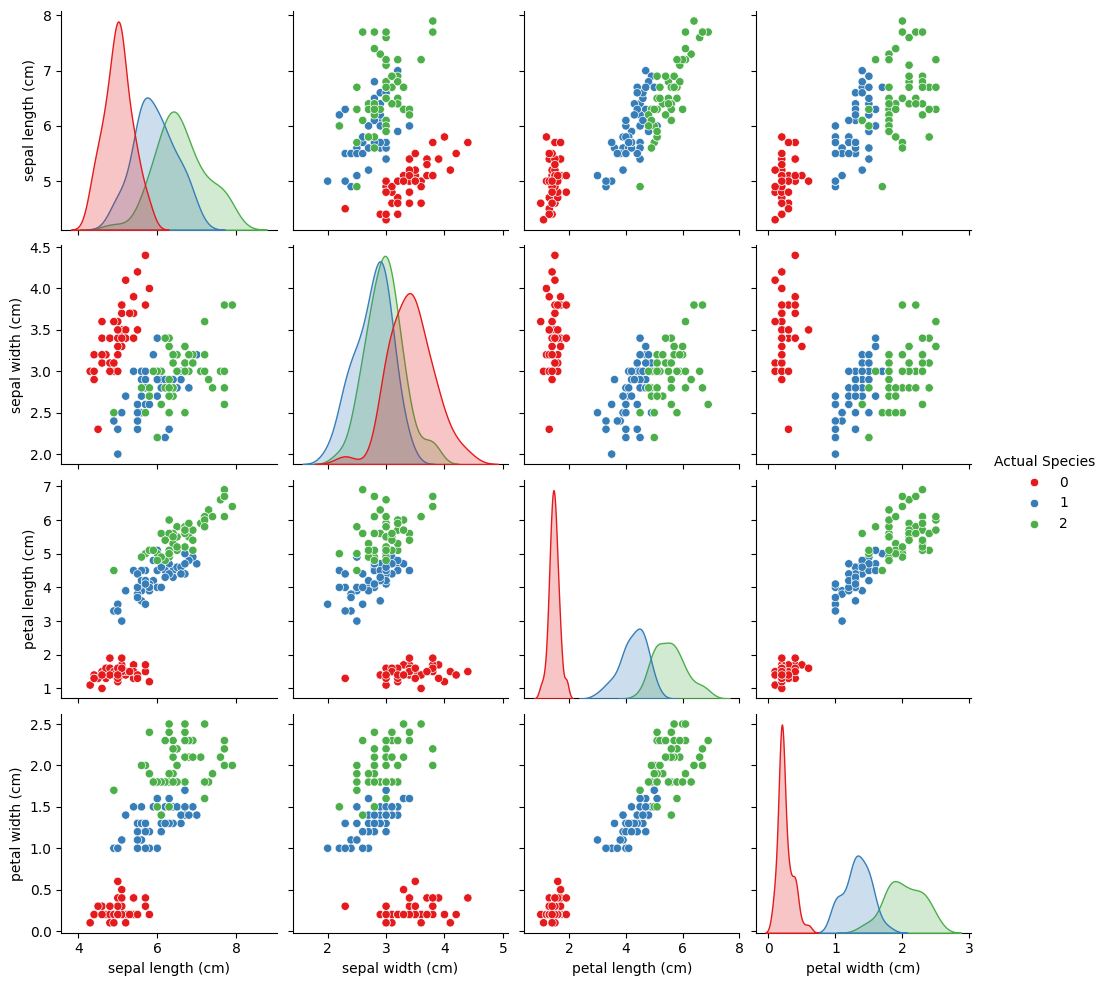

In [ ]:
sns.pairplot(
    df,
    hue="Actual Species",
    palette="Set1"
)

plt.show()



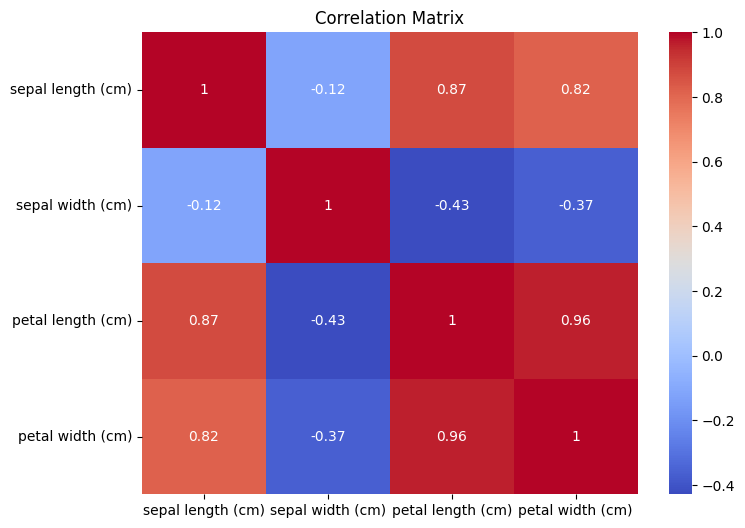

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.iloc[:,:4].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Data Shape:", X_scaled.shape)



Scaled Data Shape: (150, 4)


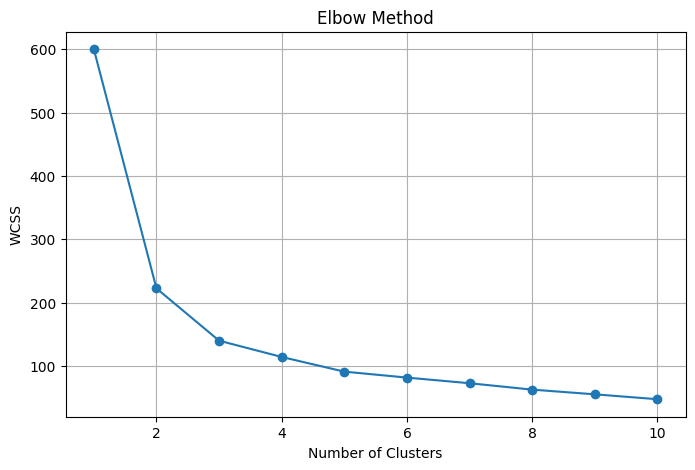

In [ ]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)

plt.show()


In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters



In [ ]:
print("\nCluster Centers (Scaled Data)\n")

print(kmeans.cluster_centers_)



Cluster Centers (Scaled Data)

[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


In [ ]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("\nSilhouette Score =", score)



Silhouette Score = 0.45994823920518635


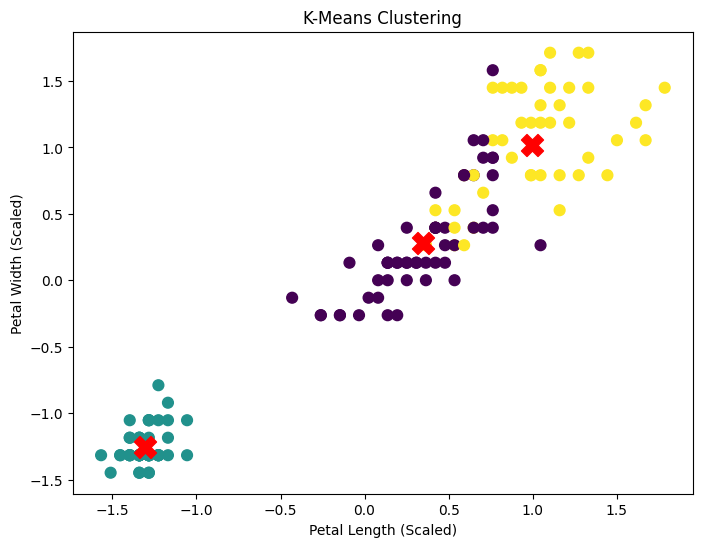

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,2],
    X_scaled[:,3],
    c=clusters,
    cmap="viridis",
    s=60
)

plt.scatter(
    kmeans.cluster_centers_[:,2],
    kmeans.cluster_centers_[:,3],
    c='red',
    marker='X',
    s=250
)

plt.title("K-Means Clustering")

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")

plt.show()


In [ ]:
print("\nActual Species vs Cluster\n")

comparison = pd.crosstab(
    df["Actual Species"],
    df["Cluster"]
)

print(comparison)



Actual Species vs Cluster

Cluster          0   1   2
Actual Species            
0                0  50   0
1               39   0  11
2               14   0  36


In [ ]:
print("\nCluster Counts\n")

print(df["Cluster"].value_counts())



Cluster Counts

Cluster
0    53
1    50
2    47
Name: count, dtype: int64


In [ ]:
print("\nFinal Dataset\n")

print(df.head(20))



Final Dataset

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                 5.1               3.5                1.4               0.2   
1                 4.9               3.0                1.4               0.2   
2                 4.7               3.2                1.3               0.2   
3                 4.6               3.1                1.5               0.2   
4                 5.0               3.6                1.4               0.2   
5                 5.4               3.9                1.7               0.4   
6                 4.6               3.4                1.4               0.3   
7                 5.0               3.4                1.5               0.2   
8                 4.4               2.9                1.4               0.2   
9                 4.9               3.1                1.5               0.1   
10                5.4               3.7                1.5               0.2   
11                4.8   

In [ ]:

print("\nCluster Means\n")

print(df.groupby("Cluster").mean(numeric_only=True))



Cluster Means

         sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster                                                           
0                 5.801887          2.673585           4.369811   
1                 5.006000          3.428000           1.462000   
2                 6.780851          3.095745           5.510638   

         petal width (cm)  Actual Species  
Cluster                                    
0                1.413208        1.264151  
1                0.246000        0.000000  
2                1.972340        1.765957  


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Online Retail (3).xlsx to Online Retail (3).xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)

df["Actual Species"] = y

print("="*60)
print("First Five Rows")
print("="*60)
print(df.head())

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)
print(df.info())

print("\n")

print("="*60)
print("Statistical Summary")
print("="*60)
print(df.describe())


First Five Rows
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Actual Species  
0               0  
1               0  
2               0  
3               0  
4               0  


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)  

In [ ]:
print("\nMissing Values\n")
print(df.isnull().sum())



Missing Values

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Actual Species       0
dtype: int64


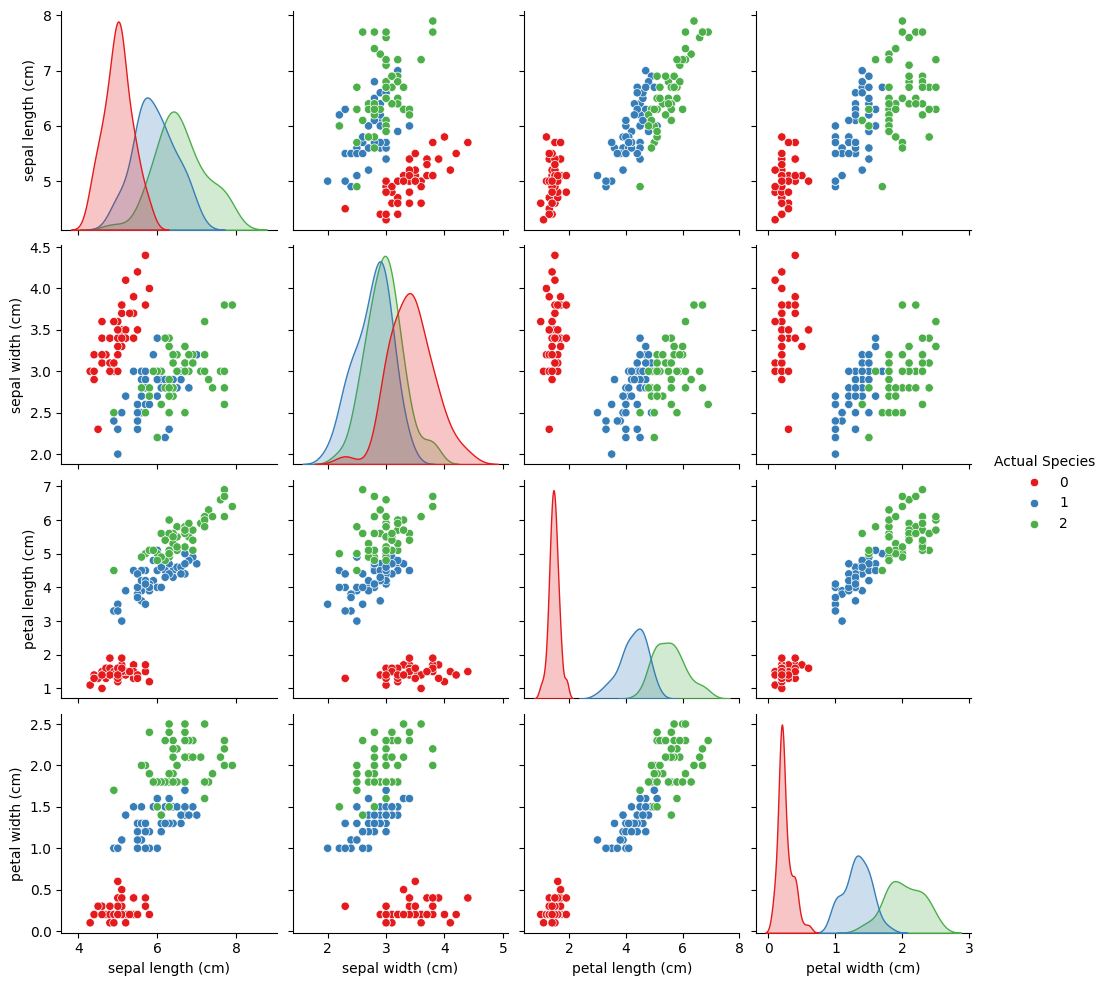

In [ ]:
sns.pairplot(
    df,
    hue="Actual Species",
    palette="Set1"
)

plt.show()



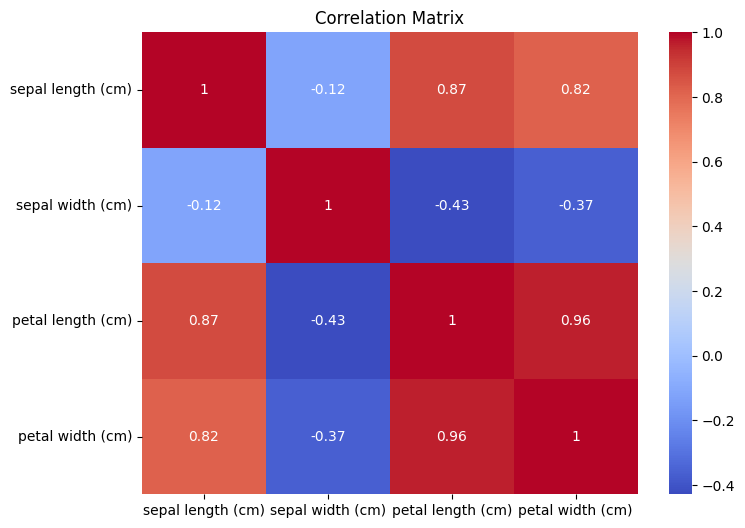

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.iloc[:,:4].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()



In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Data Shape:", X_scaled.shape)



Scaled Data Shape: (150, 4)


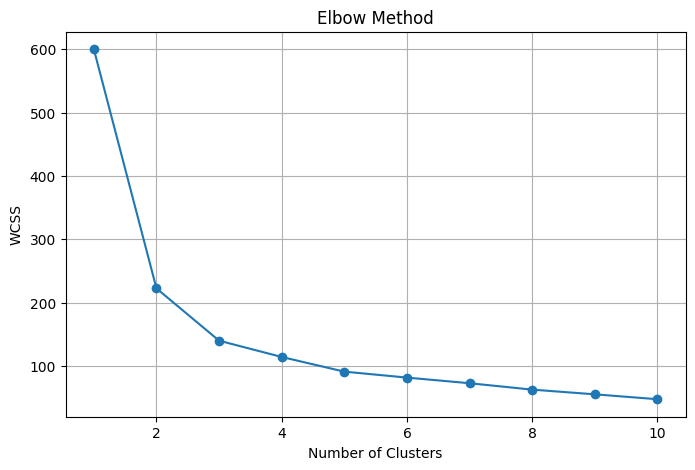

In [ ]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)

plt.show()


In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters



In [ ]:
print("\nCluster Centers (Scaled Data)\n")

print(kmeans.cluster_centers_)



Cluster Centers (Scaled Data)

[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


In [ ]:
print("\nCluster Centers (Scaled Data)\n")

print(kmeans.cluster_centers_)



Cluster Centers (Scaled Data)

[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


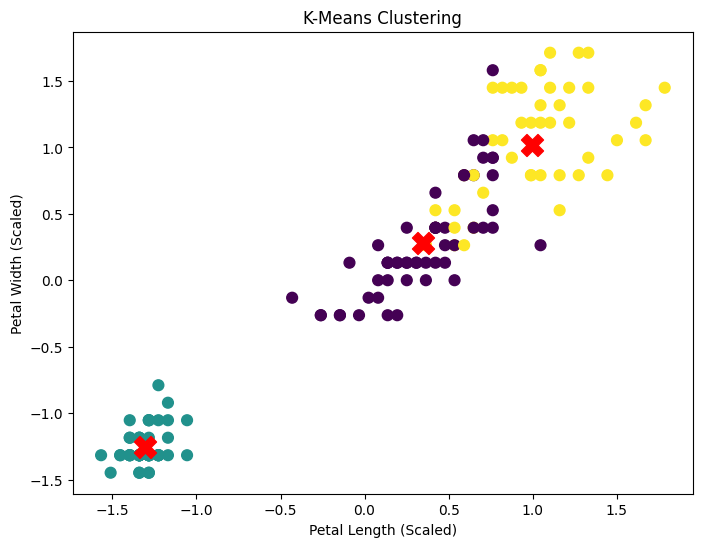

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,2],
    X_scaled[:,3],
    c=clusters,
    cmap="viridis",
    s=60
)

plt.scatter(
    kmeans.cluster_centers_[:,2],
    kmeans.cluster_centers_[:,3],
    c='red',
    marker='X',
    s=250
)

plt.title("K-Means Clustering")

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")

plt.show()



In [ ]:
print("\nActual Species vs Cluster\n")

comparison = pd.crosstab(
    df["Actual Species"],
    df["Cluster"]
)

print(comparison)



Actual Species vs Cluster

Cluster          0   1   2
Actual Species            
0                0  50   0
1               39   0  11
2               14   0  36


In [ ]:
print("\nCluster Counts\n")

print(df["Cluster"].value_counts())




Cluster Counts

Cluster
0    53
1    50
2    47
Name: count, dtype: int64


In [ ]:
print("\nFinal Dataset\n")

print(df.head(20))



Final Dataset

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                 5.1               3.5                1.4               0.2   
1                 4.9               3.0                1.4               0.2   
2                 4.7               3.2                1.3               0.2   
3                 4.6               3.1                1.5               0.2   
4                 5.0               3.6                1.4               0.2   
5                 5.4               3.9                1.7               0.4   
6                 4.6               3.4                1.4               0.3   
7                 5.0               3.4                1.5               0.2   
8                 4.4               2.9                1.4               0.2   
9                 4.9               3.1                1.5               0.1   
10                5.4               3.7                1.5               0.2   
11                4.8   

In [ ]:
print("\nCluster Means\n")

print(df.groupby("Cluster").mean(numeric_only=True))



Cluster Means

         sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster                                                           
0                 5.801887          2.673585           4.369811   
1                 5.006000          3.428000           1.462000   
2                 6.780851          3.095745           5.510638   

         petal width (cm)  Actual Species  
Cluster                                    
0                1.413208        1.264151  
1                0.246000        0.000000  
2                1.972340        1.765957  
